# 🎯 Comparação de Desempenho por Concurso Específico

## Objetivo
Comparar o desempenho das combinações de dois conjuntos:
- **Menos Padrão**: Combinações com menor padrão sequencial
- **Top 5 Padrões**: Combinações com os padrões sequenciais mais comuns

Analisaremos quantos acertos cada combinação obteve em um concurso específico.

In [1]:
# Importar bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

## 1. Carregar Dados

In [2]:
# Caminhos dos arquivos
DATA_DIR = Path('data')

# Carregar CSVs de desempenho
df_menos_padrao = pd.read_csv(DATA_DIR / 'desempenho_historico_menos_padrao.csv')
df_top5_padroes = pd.read_csv(DATA_DIR / 'desempenho_historico_top5_padroes.csv')

# Carregar sorteios históricos
df_sorteios = pd.read_csv(DATA_DIR / 'lotofacil_sorteios.csv')

print(f"📊 Combinações Menos Padrão: {len(df_menos_padrao)}")
print(f"📊 Combinações Top 5 Padrões: {len(df_top5_padroes)}")
print(f"📊 Total de Sorteios: {len(df_sorteios)}")

📊 Combinações Menos Padrão: 460
📊 Combinações Top 5 Padrões: 345
📊 Total de Sorteios: 3585


In [3]:
# Visualizar estrutura dos dados
print("\n📋 Estrutura - Menos Padrão:")
print(df_menos_padrao.head(3))

print("\n📋 Estrutura - Top 5 Padrões:")
print(df_top5_padroes.head(3))


📋 Estrutura - Menos Padrão:
   Soma  Rank                                    Combinacao  \
0   181     1  01-03-05-06-07-08-09-10-12-15-17-19-21-23-25   
1   181     2  01-03-05-07-08-09-10-11-12-14-16-18-20-22-25   
2   181     3  01-02-03-04-06-08-10-12-14-16-17-19-21-23-25   

   Score_Aleatoriedade  Acertos_11  Acertos_12  Acertos_13  Acertos_14  \
0               791.71         294          57          10           0   
1               791.71         328          71           4           0   
2               741.71         289          57           5           1   

   Acertos_15  Total_Premiados  Taxa_Premiacao_%  Melhor_Acerto  Pior_Acerto  \
0           0              361             10.07             13            6   
1           0              403             11.24             13            5   
2           0              352              9.82             14            5   

   Media_Acertos  
0           8.97  
1           9.03  
2           8.97  

📋 Estrutura - Top 5 Pad

## 2. Configurar Concurso para Análise

In [5]:
# ALTERE AQUI O CONCURSO QUE DESEJA ANALISAR
CONCURSO = 3585  # Último sorteio disponível: 12/01/2026

# Buscar resultado do concurso
resultado = df_sorteios[df_sorteios['Concurso'] == CONCURSO]

if len(resultado) == 0:
    print(f"❌ Concurso {CONCURSO} não encontrado!")
    print(f"\n📊 Concursos disponíveis: {df_sorteios['Concurso'].min()} até {df_sorteios['Concurso'].max()}")
else:
    print(f"✅ Concurso {CONCURSO} encontrado!")
    print(f"📅 Data: {resultado.iloc[0]['Data Sorteio']}")
    
    # Extrair números sorteados
    colunas_bolas = [f'Bola{i}' for i in range(1, 16)]
    numeros_sorteados = sorted(resultado[colunas_bolas].values[0].tolist())
    
    print(f"\n🎱 Números Sorteados: {numeros_sorteados}")
    print(f"📊 Soma Total: {sum(numeros_sorteados)}")

✅ Concurso 3585 encontrado!
📅 Data: 12/01/202

🎱 Números Sorteados: [1, 2, 4, 8, 9, 10, 13, 16, 17, 19, 20, 21, 22, 23, 25]
📊 Soma Total: 210


## 3. Função para Calcular Acertos

In [6]:
def calcular_acertos(combinacao_str, numeros_sorteados):
    """
    Calcula quantos números da combinação foram sorteados.
    
    Args:
        combinacao_str: String com números separados por '-' (ex: '01-02-03-04-05')
        numeros_sorteados: Lista com os números sorteados
    
    Returns:
        int: Quantidade de acertos
    """
    # Converter string para lista de inteiros
    numeros_combinacao = [int(x) for x in combinacao_str.split('-')]
    
    # Contar acertos
    acertos = len(set(numeros_combinacao) & set(numeros_sorteados))
    
    return acertos

# Testar a função
teste = calcular_acertos('01-02-03-04-05-06-07-08-09-10-11-12-13-14-15', numeros_sorteados)
print(f"✅ Teste da função: {teste} acertos")

✅ Teste da função: 7 acertos


## 4. Calcular Acertos para Todas as Combinações

In [7]:
# Calcular acertos - Menos Padrão
df_menos_padrao['Acertos_Concurso'] = df_menos_padrao['Combinacao'].apply(
    lambda x: calcular_acertos(x, numeros_sorteados)
)

# Calcular acertos - Top 5 Padrões
df_top5_padroes['Acertos_Concurso'] = df_top5_padroes['Combinacao'].apply(
    lambda x: calcular_acertos(x, numeros_sorteados)
)

print(f"✅ Acertos calculados para todas as combinações!")

✅ Acertos calculados para todas as combinações!


## 5. Estatísticas Comparativas

In [8]:
# Estatísticas descritivas
stats_menos_padrao = df_menos_padrao['Acertos_Concurso'].describe()
stats_top5_padroes = df_top5_padroes['Acertos_Concurso'].describe()

# Criar DataFrame comparativo
df_comparacao = pd.DataFrame({
    'Menos Padrão': stats_menos_padrao,
    'Top 5 Padrões': stats_top5_padroes
})

print(f"\n📊 ESTATÍSTICAS - Concurso {CONCURSO}")
print("="*60)
print(df_comparacao.round(2))
print("="*60)


📊 ESTATÍSTICAS - Concurso 3585
       Menos Padrão  Top 5 Padrões
count        460.00         345.00
mean           9.17           9.22
std            1.17           0.88
min            6.00           7.00
25%            8.00           9.00
50%            9.00           9.00
75%           10.00          10.00
max           12.00          12.00


In [9]:
# Distribuição de acertos
print(f"\n🎯 DISTRIBUIÇÃO DE ACERTOS - Concurso {CONCURSO}\n")

print("📌 Menos Padrão:")
dist_menos = df_menos_padrao['Acertos_Concurso'].value_counts().sort_index()
for acertos, qtd in dist_menos.items():
    pct = (qtd / len(df_menos_padrao)) * 100
    print(f"   {acertos} acertos: {qtd:4d} combinações ({pct:5.2f}%)")

print("\n📌 Top 5 Padrões:")
dist_top5 = df_top5_padroes['Acertos_Concurso'].value_counts().sort_index()
for acertos, qtd in dist_top5.items():
    pct = (qtd / len(df_top5_padroes)) * 100
    print(f"   {acertos} acertos: {qtd:4d} combinações ({pct:5.2f}%)")


🎯 DISTRIBUIÇÃO DE ACERTOS - Concurso 3585

📌 Menos Padrão:
   6 acertos:    3 combinações ( 0.65%)
   7 acertos:   31 combinações ( 6.74%)
   8 acertos:   96 combinações (20.87%)
   9 acertos:  149 combinações (32.39%)
   10 acertos:  123 combinações (26.74%)
   11 acertos:   50 combinações (10.87%)
   12 acertos:    8 combinações ( 1.74%)

📌 Top 5 Padrões:
   7 acertos:    7 combinações ( 2.03%)
   8 acertos:   56 combinações (16.23%)
   9 acertos:  160 combinações (46.38%)
   10 acertos:  101 combinações (29.28%)
   11 acertos:   18 combinações ( 5.22%)
   12 acertos:    3 combinações ( 0.87%)


## 6. Identificar Melhores Combinações

In [10]:
# Top 10 - Menos Padrão
top10_menos = df_menos_padrao.nlargest(10, 'Acertos_Concurso')[[
    'Soma', 'Rank', 'Combinacao', 'Score_Aleatoriedade', 'Acertos_Concurso'
]]

print(f"\n🏆 TOP 10 COMBINAÇÕES - Menos Padrão (Concurso {CONCURSO})")
print("="*100)
print(top10_menos.to_string(index=False))
print("="*100)


🏆 TOP 10 COMBINAÇÕES - Menos Padrão (Concurso 3585)
 Soma  Rank                                   Combinacao  Score_Aleatoriedade  Acertos_Concurso
  183    18 01-02-03-04-06-08-10-13-15-16-17-19-21-23-25               631.71                12
  184     4 01-02-04-06-08-09-10-11-13-15-17-19-21-23-25               741.71                12
  187    18 01-02-03-04-06-08-10-13-15-17-19-20-21-23-25               631.71                12
  189    18 01-02-03-04-06-08-10-13-15-17-19-21-22-23-25               631.71                12
  194    20 01-02-04-06-08-10-13-14-15-16-17-19-21-23-25               631.71                12
  198    18 01-02-04-06-08-10-13-15-16-17-18-19-21-23-25               631.71                12
  202    16 01-02-04-06-08-10-13-15-17-18-19-20-21-23-25               631.71                12
  203    17 01-02-04-06-08-10-12-14-16-19-20-21-22-23-25               631.71                12
  181     3 01-02-03-04-06-08-10-12-14-16-17-19-21-23-25               741.71      

In [11]:
# Top 10 - Top 5 Padrões
top10_padroes = df_top5_padroes.nlargest(10, 'Acertos_Concurso')[[
    'Soma', 'Rank_Padrao', 'Padrao', 'Combinacao', 'Acertos_Concurso'
]]

print(f"\n🏆 TOP 10 COMBINAÇÕES - Top 5 Padrões (Concurso {CONCURSO})")
print("="*100)
print(top10_padroes.to_string(index=False))
print("="*100)


🏆 TOP 10 COMBINAÇÕES - Top 5 Padrões (Concurso 3585)
 Soma  Rank_Padrao          Padrao                                   Combinacao  Acertos_Concurso
  199            3    (4, 3, 3, 2) 01-02-03-04-06-08-10-16-17-19-20-21-23-24-25                12
  202            2    (4, 3, 3, 2) 01-02-03-04-06-08-13-16-17-19-20-21-23-24-25                12
  203            3    (4, 3, 3, 2) 01-02-03-04-06-09-13-16-17-19-20-21-23-24-25                12
  181            1 (4, 3, 2, 2, 2) 01-02-03-04-06-07-08-10-15-16-19-20-22-23-25                11
  181            2    (4, 3, 2, 2) 01-02-03-04-06-07-08-10-13-16-19-21-22-24-25                11
  181            2    (4, 3, 2, 2) 01-02-03-04-06-07-08-10-13-17-19-20-22-24-25                11
  182            1    (4, 3, 2, 2) 01-02-03-04-06-07-08-10-13-17-19-21-22-24-25                11
  183            4    (5, 3, 2, 2) 01-02-03-04-05-07-08-10-13-17-20-21-23-24-25                11
  184            2    (4, 3, 3, 2) 01-02-03-04-06-07-08-10-13-17

## 7. Análise de Premiação

In [12]:
# Contar combinações premiadas (11+ acertos)
premiadas_menos = (df_menos_padrao['Acertos_Concurso'] >= 11).sum()
premiadas_top5 = (df_top5_padroes['Acertos_Concurso'] >= 11).sum()

# Contar por faixa de premiação
acertos_11_menos = (df_menos_padrao['Acertos_Concurso'] == 11).sum()
acertos_12_menos = (df_menos_padrao['Acertos_Concurso'] == 12).sum()
acertos_13_menos = (df_menos_padrao['Acertos_Concurso'] == 13).sum()
acertos_14_menos = (df_menos_padrao['Acertos_Concurso'] == 14).sum()
acertos_15_menos = (df_menos_padrao['Acertos_Concurso'] == 15).sum()

acertos_11_top5 = (df_top5_padroes['Acertos_Concurso'] == 11).sum()
acertos_12_top5 = (df_top5_padroes['Acertos_Concurso'] == 12).sum()
acertos_13_top5 = (df_top5_padroes['Acertos_Concurso'] == 13).sum()
acertos_14_top5 = (df_top5_padroes['Acertos_Concurso'] == 14).sum()
acertos_15_top5 = (df_top5_padroes['Acertos_Concurso'] == 15).sum()

print(f"\n💰 ANÁLISE DE PREMIAÇÃO - Concurso {CONCURSO}")
print("="*80)
print(f"\n📌 Menos Padrão ({len(df_menos_padrao)} combinações):")
print(f"   Total Premiadas (11+): {premiadas_menos} ({premiadas_menos/len(df_menos_padrao)*100:.2f}%)")
print(f"   - 11 acertos: {acertos_11_menos}")
print(f"   - 12 acertos: {acertos_12_menos}")
print(f"   - 13 acertos: {acertos_13_menos}")
print(f"   - 14 acertos: {acertos_14_menos}")
print(f"   - 15 acertos: {acertos_15_menos} {'🎉🎉🎉' if acertos_15_menos > 0 else ''}")

print(f"\n📌 Top 5 Padrões ({len(df_top5_padroes)} combinações):")
print(f"   Total Premiadas (11+): {premiadas_top5} ({premiadas_top5/len(df_top5_padroes)*100:.2f}%)")
print(f"   - 11 acertos: {acertos_11_top5}")
print(f"   - 12 acertos: {acertos_12_top5}")
print(f"   - 13 acertos: {acertos_13_top5}")
print(f"   - 14 acertos: {acertos_14_top5}")
print(f"   - 15 acertos: {acertos_15_top5} {'🎉🎉🎉' if acertos_15_top5 > 0 else ''}")
print("="*80)


💰 ANÁLISE DE PREMIAÇÃO - Concurso 3585

📌 Menos Padrão (460 combinações):
   Total Premiadas (11+): 58 (12.61%)
   - 11 acertos: 50
   - 12 acertos: 8
   - 13 acertos: 0
   - 14 acertos: 0
   - 15 acertos: 0 

📌 Top 5 Padrões (345 combinações):
   Total Premiadas (11+): 21 (6.09%)
   - 11 acertos: 18
   - 12 acertos: 3
   - 13 acertos: 0
   - 14 acertos: 0
   - 15 acertos: 0 


## 8. Visualizações

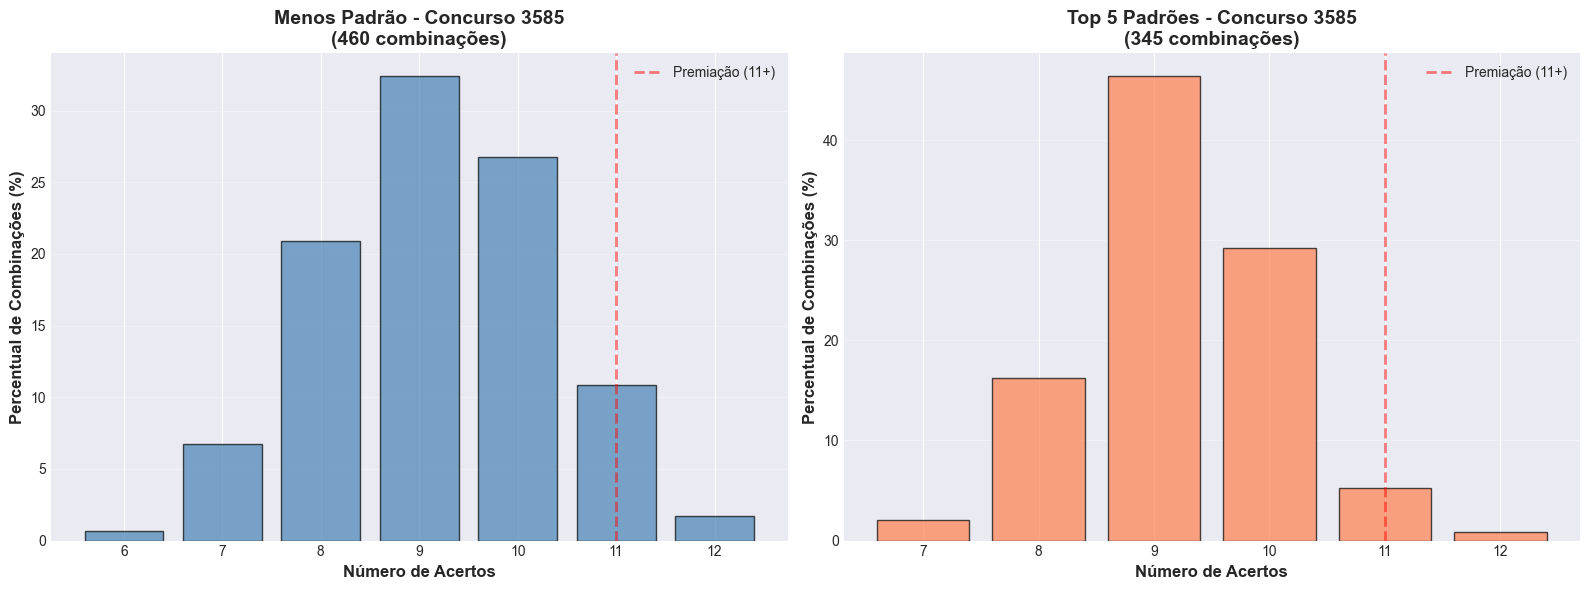


✅ Gráfico salvo: out/comparacao_acertos_concurso_3585.png


In [13]:
# Gráfico de barras comparativo - Distribuição de acertos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Menos Padrão
dist_menos_pct = (df_menos_padrao['Acertos_Concurso'].value_counts().sort_index() / len(df_menos_padrao)) * 100
ax1.bar(dist_menos_pct.index, dist_menos_pct.values, color='steelblue', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Número de Acertos', fontsize=12, fontweight='bold')
ax1.set_ylabel('Percentual de Combinações (%)', fontsize=12, fontweight='bold')
ax1.set_title(f'Menos Padrão - Concurso {CONCURSO}\n({len(df_menos_padrao)} combinações)', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.axvline(x=11, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Premiação (11+)')
ax1.legend()

# Top 5 Padrões
dist_top5_pct = (df_top5_padroes['Acertos_Concurso'].value_counts().sort_index() / len(df_top5_padroes)) * 100
ax2.bar(dist_top5_pct.index, dist_top5_pct.values, color='coral', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Número de Acertos', fontsize=12, fontweight='bold')
ax2.set_ylabel('Percentual de Combinações (%)', fontsize=12, fontweight='bold')
ax2.set_title(f'Top 5 Padrões - Concurso {CONCURSO}\n({len(df_top5_padroes)} combinações)', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.axvline(x=11, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Premiação (11+)')
ax2.legend()

plt.tight_layout()
plt.savefig(f'out/comparacao_acertos_concurso_{CONCURSO}.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Gráfico salvo: out/comparacao_acertos_concurso_{CONCURSO}.png")

C:\Users\wmaldonado\AppData\Local\Temp\ipykernel_13176\1221350029.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_plot, labels=['Menos Padrão', 'Top 5 Padrões'],


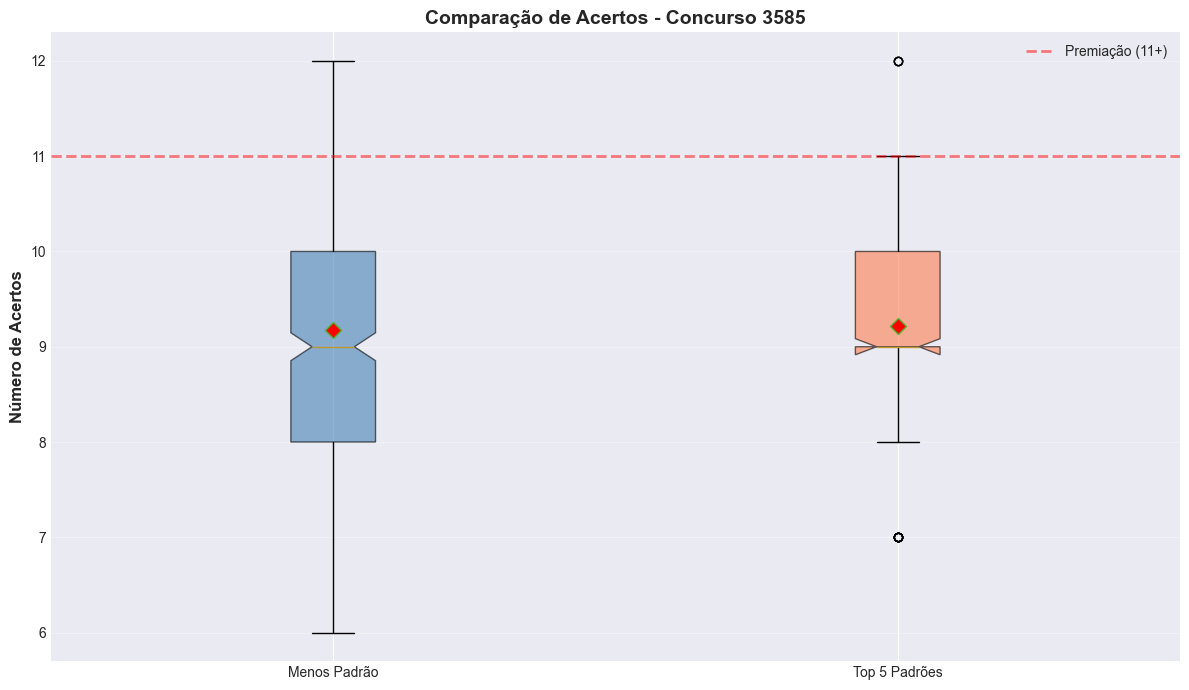


✅ Box plot salvo: out/boxplot_acertos_concurso_3585.png


In [14]:
# Box plot comparativo
fig, ax = plt.subplots(figsize=(12, 7))

data_plot = [
    df_menos_padrao['Acertos_Concurso'],
    df_top5_padroes['Acertos_Concurso']
]

bp = ax.boxplot(data_plot, labels=['Menos Padrão', 'Top 5 Padrões'], 
                patch_artist=True, notch=True, showmeans=True,
                meanprops=dict(marker='D', markerfacecolor='red', markersize=8))

# Colorir as caixas
colors = ['steelblue', 'coral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel('Número de Acertos', fontsize=12, fontweight='bold')
ax.set_title(f'Comparação de Acertos - Concurso {CONCURSO}', fontsize=14, fontweight='bold')
ax.axhline(y=11, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Premiação (11+)')
ax.grid(axis='y', alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig(f'out/boxplot_acertos_concurso_{CONCURSO}.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Box plot salvo: out/boxplot_acertos_concurso_{CONCURSO}.png")

## 9. Exportar Resultados

In [15]:
# Exportar combinações com acertos
output_menos = df_menos_padrao.sort_values('Acertos_Concurso', ascending=False)
output_top5 = df_top5_padroes.sort_values('Acertos_Concurso', ascending=False)

output_menos.to_csv(f'out/resultado_menos_padrao_concurso_{CONCURSO}.csv', index=False)
output_top5.to_csv(f'out/resultado_top5_padroes_concurso_{CONCURSO}.csv', index=False)

print(f"\n✅ Arquivos exportados:")
print(f"   - out/resultado_menos_padrao_concurso_{CONCURSO}.csv")
print(f"   - out/resultado_top5_padroes_concurso_{CONCURSO}.csv")


✅ Arquivos exportados:
   - out/resultado_menos_padrao_concurso_3585.csv
   - out/resultado_top5_padroes_concurso_3585.csv


## 10. Resumo Final

In [16]:
print(f"\n{'='*80}")
print(f"🎯 RESUMO FINAL - Concurso {CONCURSO}")
print(f"{'='*80}")

print(f"\n📅 Data: {resultado.iloc[0]['Data Sorteio']}")
print(f"🎱 Números: {numeros_sorteados}")
print(f"📊 Soma: {sum(numeros_sorteados)}")

print(f"\n📌 MENOS PADRÃO ({len(df_menos_padrao)} combinações):")
print(f"   Média de acertos: {df_menos_padrao['Acertos_Concurso'].mean():.2f}")
print(f"   Melhor resultado: {df_menos_padrao['Acertos_Concurso'].max()} acertos")
print(f"   Pior resultado: {df_menos_padrao['Acertos_Concurso'].min()} acertos")
print(f"   Premiadas (11+): {premiadas_menos} ({premiadas_menos/len(df_menos_padrao)*100:.2f}%)")

print(f"\n📌 TOP 5 PADRÕES ({len(df_top5_padroes)} combinações):")
print(f"   Média de acertos: {df_top5_padroes['Acertos_Concurso'].mean():.2f}")
print(f"   Melhor resultado: {df_top5_padroes['Acertos_Concurso'].max()} acertos")
print(f"   Pior resultado: {df_top5_padroes['Acertos_Concurso'].min()} acertos")
print(f"   Premiadas (11+): {premiadas_top5} ({premiadas_top5/len(df_top5_padroes)*100:.2f}%)")

# Determinar vencedor
if df_menos_padrao['Acertos_Concurso'].mean() > df_top5_padroes['Acertos_Concurso'].mean():
    print(f"\n🏆 VENCEDOR: Menos Padrão (+{df_menos_padrao['Acertos_Concurso'].mean() - df_top5_padroes['Acertos_Concurso'].mean():.2f} acertos em média)")
elif df_menos_padrao['Acertos_Concurso'].mean() < df_top5_padroes['Acertos_Concurso'].mean():
    print(f"\n🏆 VENCEDOR: Top 5 Padrões (+{df_top5_padroes['Acertos_Concurso'].mean() - df_menos_padrao['Acertos_Concurso'].mean():.2f} acertos em média)")
else:
    print(f"\n🤝 EMPATE!")

print(f"\n{'='*80}")


🎯 RESUMO FINAL - Concurso 3585

📅 Data: 12/01/202
🎱 Números: [1, 2, 4, 8, 9, 10, 13, 16, 17, 19, 20, 21, 22, 23, 25]
📊 Soma: 210

📌 MENOS PADRÃO (460 combinações):
   Média de acertos: 9.17
   Melhor resultado: 12 acertos
   Pior resultado: 6 acertos
   Premiadas (11+): 58 (12.61%)

📌 TOP 5 PADRÕES (345 combinações):
   Média de acertos: 9.22
   Melhor resultado: 12 acertos
   Pior resultado: 7 acertos
   Premiadas (11+): 21 (6.09%)

🏆 VENCEDOR: Top 5 Padrões (+0.05 acertos em média)



## 11. Análise Adicional: Testar Múltiplos Concursos

In [17]:
# Função para analisar um concurso específico
def analisar_concurso(concurso_num, df_sorteios, df_menos, df_top5):
    """
    Analisa o desempenho das combinações em um concurso específico.
    """
    # Buscar resultado
    resultado = df_sorteios[df_sorteios['Concurso'] == concurso_num]
    
    if len(resultado) == 0:
        return None
    
    # Extrair números sorteados
    colunas_bolas = [f'Bola{i}' for i in range(1, 16)]
    numeros = sorted(resultado[colunas_bolas].values[0].tolist())
    
    # Calcular acertos
    acertos_menos = df_menos['Combinacao'].apply(lambda x: calcular_acertos(x, numeros))
    acertos_top5 = df_top5['Combinacao'].apply(lambda x: calcular_acertos(x, numeros))
    
    return {
        'Concurso': concurso_num,
        'Data': resultado.iloc[0]['Data Sorteio'],
        'Soma': sum(numeros),
        'Media_Menos_Padrao': acertos_menos.mean(),
        'Max_Menos_Padrao': acertos_menos.max(),
        'Premiadas_Menos_Padrao': (acertos_menos >= 11).sum(),
        'Media_Top5_Padroes': acertos_top5.mean(),
        'Max_Top5_Padroes': acertos_top5.max(),
        'Premiadas_Top5_Padroes': (acertos_top5 >= 11).sum()
    }

print("✅ Função criada para análise de múltiplos concursos")
print("\n💡 Para usar, execute:")
print("   resultados = [analisar_concurso(c, df_sorteios, df_menos_padrao, df_top5_padroes) for c in range(3570, 3586)]")
print("   df_analise = pd.DataFrame([r for r in resultados if r is not None])")

✅ Função criada para análise de múltiplos concursos

💡 Para usar, execute:
   resultados = [analisar_concurso(c, df_sorteios, df_menos_padrao, df_top5_padroes) for c in range(3570, 3586)]
   df_analise = pd.DataFrame([r for r in resultados if r is not None])


In [18]:
# Exemplo: Analisar os últimos 20 concursos
ultimo_concurso = df_sorteios['Concurso'].max()
primeiro_concurso = ultimo_concurso - 19

print(f"📊 Analisando concursos {primeiro_concurso} a {ultimo_concurso}...\n")

resultados_multiplos = []
for c in range(primeiro_concurso, ultimo_concurso + 1):
    res = analisar_concurso(c, df_sorteios, df_menos_padrao, df_top5_padroes)
    if res:
        resultados_multiplos.append(res)

df_analise_multipla = pd.DataFrame(resultados_multiplos)

# Resumo
print("\n📊 RESUMO DOS ÚLTIMOS 20 CONCURSOS:")
print("="*80)
print(f"\nMenos Padrão:")
print(f"   Média geral de acertos: {df_analise_multipla['Media_Menos_Padrao'].mean():.2f}")
print(f"   Total de premiadas (11+): {df_analise_multipla['Premiadas_Menos_Padrao'].sum()}")
print(f"   Máximo de acertos: {df_analise_multipla['Max_Menos_Padrao'].max()}")

print(f"\nTop 5 Padrões:")
print(f"   Média geral de acertos: {df_analise_multipla['Media_Top5_Padroes'].mean():.2f}")
print(f"   Total de premiadas (11+): {df_analise_multipla['Premiadas_Top5_Padroes'].sum()}")
print(f"   Máximo de acertos: {df_analise_multipla['Max_Top5_Padroes'].max()}")
print("="*80)

# Exportar
df_analise_multipla.to_csv('out/analise_ultimos_20_concursos.csv', index=False)
print("\n✅ Resultados exportados: out/analise_ultimos_20_concursos.csv")

📊 Analisando concursos 3566 a 3585...


📊 RESUMO DOS ÚLTIMOS 20 CONCURSOS:

Menos Padrão:
   Média geral de acertos: 8.83
   Total de premiadas (11+): 927
   Máximo de acertos: 14

Top 5 Padrões:
   Média geral de acertos: 9.22
   Total de premiadas (11+): 897
   Máximo de acertos: 13

✅ Resultados exportados: out/analise_ultimos_20_concursos.csv
